# Bounding box detection - Racoon data


## Data files
- images_racoon.rar: contain images of racoons
- train_labels.cv: contains coordinates for bounding box for every image

### Import the necessary libraries

In [0]:
#Clone git repo tensorflow/models
!git clone https://github.com/tensorflow/models

Cloning into 'models'...
remote: Enumerating objects: 32055, done.
remote: Total 32055 (delta 0), reused 0 (delta 0), pack-reused 32055
Receiving objects: 100% (32055/32055), 511.21 MiB | 14.49 MiB/s, done.
Resolving deltas: 100% (20308/20308), done.
Checking out files: 100% (3135/3135), done.


In [0]:
#Verify that models folder exist
!ls -l

total 8
drwxr-xr-x 7 root root 4096 Nov  3 12:22 models
drwxr-xr-x 1 root root 4096 Oct 25 16:58 sample_data


In [0]:
#Multiple folders including object_detection should exist in models/research folder
!ls -l models/research/

total 280
drwxr-xr-x  2 root root 4096 Nov  3 12:22 a3c_blogpost
drwxr-xr-x  2 root root 4096 Nov  3 12:22 adversarial_crypto
drwxr-xr-x  4 root root 4096 Nov  3 12:22 adversarial_logit_pairing
drwxr-xr-x  3 root root 4096 Nov  3 12:22 adversarial_text
drwxr-xr-x  2 root root 4096 Nov  3 12:22 adv_imagenet_models
drwxr-xr-x  2 root root 4096 Nov  3 12:22 astronet
drwxr-xr-x  3 root root 4096 Nov  3 12:22 attention_ocr
drwxr-xr-x  3 root root 4096 Nov  3 12:22 audioset
drwxr-xr-x  2 root root 4096 Nov  3 12:22 autoaugment
drwxr-xr-x  3 root root 4096 Nov  3 12:22 autoencoder
drwxr-xr-x  4 root root 4096 Nov  3 12:22 brain_coder
drwxr-xr-x 11 root root 4096 Nov  3 12:22 cognitive_mapping_and_planning
drwxr-xr-x  4 root root 4096 Nov  3 12:22 cognitive_planning
drwxr-xr-x  4 root root 4096 Nov  3 12:22 compression
drwxr-xr-x  7 root root 4096 Nov  3 12:22 cvt_text
drwxr-xr-x  3 root root 4096 Nov  3 12:22 deep_contextual_bandits
drwxr-xr-x  9 root root 4096 Nov  3 12:22 deeplab
drwxr-xr-x

In [0]:
#Install other dependencies including protobuf compiler
!apt-get -qq install protobuf-compiler python-pil python-lxml python-tk
!pip install --user Cython  --quiet
!pip install --user contextlib2 --quiet
!pip install --user jupyter --quiet
!pip install --user matplotlib --quiet

Selecting previously unselected package python-bs4.
(Reading database ... 132681 files and directories currently installed.)
Preparing to unpack .../0-python-bs4_4.6.0-1_all.deb ...
Unpacking python-bs4 (4.6.0-1) ...
Selecting previously unselected package python-pkg-resources.
Preparing to unpack .../1-python-pkg-resources_39.0.1-2_all.deb ...
Unpacking python-pkg-resources (39.0.1-2) ...
Selecting previously unselected package python-chardet.
Preparing to unpack .../2-python-chardet_3.0.4-1_all.deb ...
Unpacking python-chardet (3.0.4-1) ...
Selecting previously unselected package python-six.
Preparing to unpack .../3-python-six_1.11.0-2_all.deb ...
Unpacking python-six (1.11.0-2) ...
Selecting previously unselected package python-webencodings.
Preparing to unpack .../4-python-webencodings_0.5-2_all.deb ...
Unpacking python-webencodings (0.5-2) ...
Selecting previously unselected package python-html5lib.
Preparing to unpack .../5-python-html5lib_0.999999999-1_all.deb ...
Unpacking pyt

Protobuf compilation

Convert .pb files to python code in object detection folder

In [0]:
%cd models/research
!protoc object_detection/protos/*.proto --python_out=.

/content/models/research


In [0]:
!ls -l object_detection/protos

total 724
-rw-r--r-- 1 root root   6848 Nov  3 12:24 anchor_generator_pb2.py
-rw-r--r-- 1 root root    747 Nov  3 12:22 anchor_generator.proto
-rw-r--r-- 1 root root   4359 Nov  3 12:24 argmax_matcher_pb2.py
-rw-r--r-- 1 root root   1151 Nov  3 12:22 argmax_matcher.proto
-rw-r--r-- 1 root root   2175 Nov  3 12:24 bipartite_matcher_pb2.py
-rw-r--r-- 1 root root    350 Nov  3 12:22 bipartite_matcher.proto
-rw-r--r-- 1 root root   6208 Nov  3 12:24 box_coder_pb2.py
-rw-r--r-- 1 root root    656 Nov  3 12:22 box_coder.proto
-rw-r--r-- 1 root root  35788 Nov  3 12:24 box_predictor_pb2.py
-rw-r--r-- 1 root root   7366 Nov  3 12:22 box_predictor.proto
-rw-r--r-- 1 root root  24908 Nov  3 12:24 calibration_pb2.py
-rw-r--r-- 1 root root   2876 Nov  3 12:22 calibration.proto
-rw-r--r-- 1 root root  13121 Nov  3 12:24 eval_pb2.py
-rw-r--r-- 1 root root   3642 Nov  3 12:22 eval.proto
-rw-r--r-- 1 root root   3445 Nov  3 12:24 faster_rcnn_box_coder_pb2.py
-rw-r--r-- 1 root root    531 Nov  3 12:22 

In [0]:
#Setup environment variable
%set_env PYTHONPATH=$PYTHONPATH:/content/models/research:/content/models/research/slim

# Test Installation
# #To be run from models/research folder
!python object_detection/builders/model_builder_test.py

env: PYTHONPATH=$PYTHONPATH:/content/models/research:/content/models/research/slim
The TensorFlow contrib module will not be included in TensorFlow 2.0.
For more information, please see:
  * https://github.com/tensorflow/community/blob/master/rfcs/20180907-contrib-sunset.md
  * https://github.com/tensorflow/addons
  * https://github.com/tensorflow/io (for I/O related ops)
If you depend on functionality not listed there, please file an issue.



Running tests under Python 3.6.8: /usr/bin/python3
[ RUN      ] ModelBuilderTest.test_create_experimental_model
[       OK ] ModelBuilderTest.test_create_experimental_model
[ RUN      ] ModelBuilderTest.test_create_faster_rcnn_model_from_config_with_example_miner
[       OK ] ModelBuilderTest.test_create_faster_rcnn_model_from_config_with_example_miner
[ RUN      ] ModelBuilderTest.test_create_faster_rcnn_models_from_config_faster_rcnn_with_matmul
[       OK ] ModelBuilderTest.test_create_faster_rcnn_models_from_config_faster_rcnn_with_matmul
[ 

In [0]:
from google.colab import drive
drive.mount('/content/drive')

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3Aietf%3Awg%3Aoauth%3A2.0%3Aoob&scope=email%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdocs.test%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive.photos.readonly%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fpeopleapi.readonly&response_type=code

Enter your authorization code:
··········
Mounted at /content/drive


In [0]:
#### Download Racoon dataset
#Create and move to Racoon directory
#Come to the home directory
%cd /content

#Create a folder for your project e.g in this case, pascal voc. You can choose any name for the folder 
!mkdir racoon

#Go to the project folder
%cd racoon
!ls -l

/content
/content/racoon
total 0


In [0]:
#Download dataset
#Get dataset
#!wget http://pjreddie.com/media/files/VOCtrainval_06-Nov-2007.tar --quiet

In [0]:
#Check the project folder
#!ls -l

In [0]:
!pip install patool

     |████████████████████████████████| 81kB 2.6MB/s 


In [0]:
#Read the dataset
#import tarfile
#dataset = tarfile.open('VOCtrainval_06-Nov-2007.tar')
#Extract files to the disk
#dataset.extractall(path='')

#import zipfile as zf
#dataset = zf.ZipFile('/content/drive/My Drive/GL_AIML/Residency_9/external_lab/images_racoon.rar')
#Extract files to the disk
#dataset.extractall(path='')
#!ls
import patoolib
patoolib.extract_archive("/content/drive/My Drive/GL_AIML/Residency_9/external_lab/images_racoon.rar", outdir="/content/racoon")

patool: Extracting /content/drive/My Drive/GL_AIML/Residency_9/external_lab/images_racoon.rar ...
patool: running /usr/bin/unrar x -- "/content/drive/My Drive/GL_AIML/Residency_9/external_lab/images_racoon.rar"
patool:     with cwd='/content/racoon'
patool: ... /content/drive/My Drive/GL_AIML/Residency_9/external_lab/images_racoon.rar extracted to `/content/racoon'.


'/content/racoon'

In [0]:
!ls -l

total 12
drwxr-xr-x 3 root root 12288 Apr 22  2019 images


In [0]:
!pwd
!ls -l images | wc -l

/content/racoon
202


In [0]:
# Load Lable .csv file
import pandas as pd
df = pd.read_csv('/content/drive/My Drive/GL_AIML/Residency_9/external_lab/train_labels.csv')
df.head()

,filename,width,height,class,xmin,ymin,xmax,ymax
0,raccoon-17.jpg,259,194,raccoon,95,60,167,118
1,raccoon-11.jpg,660,432,raccoon,3,1,461,431
2,raccoon-63.jpg,600,400,raccoon,74,107,280,290
3,raccoon-63.jpg,600,400,raccoon,227,93,403,298
4,raccoon-60.jpg,273,185,raccoon,58,33,197,127


In [0]:
#How many object across all images
print(df.shape)

(173, 8)


In [0]:
#List of labels
df['class'].unique()

array(['raccoon'], dtype=object)

In [0]:
#Number of labels
len(df['class'].unique())

1

In [0]:
from sklearn import preprocessing

In [33]:
#Label encode Class 
le = preprocessing.LabelEncoder()
df['label'] = le.fit_transform(df['class'])
df.head()

,filename,width,height,class,xmin,ymin,xmax,ymax,label
0,raccoon-17.jpg,259,194,raccoon,95,60,167,118,0
1,raccoon-11.jpg,660,432,raccoon,3,1,461,431,0
2,raccoon-63.jpg,600,400,raccoon,74,107,280,290,0
3,raccoon-63.jpg,600,400,raccoon,227,93,403,298,0
4,raccoon-60.jpg,273,185,raccoon,58,33,197,127,0


In [34]:
#unique values in the label
df.label.unique()

array([0])

In [35]:
#Object detection API expects index to start from 1 (and not 0)
df['label'] = df['label'] + 1
df.label.unique()

array([1])

In [36]:
#Create a dictionary of Label and Clas
label_class_dict = dict(zip(df['label'], df['class']))
label_class_dict

{1: 'raccoon'}

### Change directory

### Load the training data from train.csv file

In [0]:
import numpy as np

#80% of the data will be used for training
mask = np.random.rand(len(df)) < 0.8
train_df = df[mask]
test_df = df[~mask]

In [38]:
train_df.shape, test_df.shape

((139, 9), (34, 9))

In [0]:
#Visualizing the data
from matplotlib import pyplot as plt
import cv2

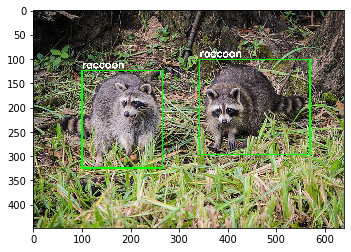

In [42]:
#Pickup a random image number
img_num = np.random.randint(0, df.shape[0])

#Read the image
img_file = df.loc[img_num,'filename']
img = cv2.imread('images/' + img_file)

#Find all rows which have same file name
rows_with_file = df[df['filename'] == img_file].index.tolist()

#Draw rectangle(s) as per bounding box information
for i in rows_with_file:

    #Get bounding box
    xmin, ymin, xmax, ymax = df.loc[i, ['xmin', 'ymin', 'xmax', 'ymax']]
    #Get Label
    label = df.loc[i, 'class']
    #Add bounding box
    cv2.rectangle(img, (xmin,ymin), (xmax, ymax), (0,255,0), 2)
    #Add text
    cv2.putText(img,label,(xmin, ymin-5),cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

#Convert BGR format (used by opencv to RGB format used by matplotlib)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

#Draw image using matplotlib
plt.imshow(img)
plt.show()

In [0]:
#Save training and test data as csv
train_df.to_csv('train.csv', index=False)
test_df.to_csv('test.csv', index=False)

In [57]:
#### Generate tfrecord from CSV
#Tensorflow object detection API requires data in tfrecord format. This can be done using generate_tfrecord.py file.
#To be done for colab only - copy generate_tfrecord.py file in current directory
from google.colab import files
files.upload()

Saving generate_tfrecord.py to generate_tfrecord.py


{'generate_tfrecord.py': b'"""\r\nUsage:\r\n\r\n# Create train data:\r\npython generate_tfrecord.py --label=<LABEL> --csv_input=<PATH_TO_ANNOTATIONS_FOLDER>/train_labels.csv  --output_path=<PATH_TO_ANNOTATIONS_FOLDER>/train.record\r\n\r\n# Create test data:\r\npython generate_tfrecord.py --label=<LABEL> --csv_input=<PATH_TO_ANNOTATIONS_FOLDER>/test_labels.csv  --output_path=<PATH_TO_ANNOTATIONS_FOLDER>/test.record\r\n"""\r\n\r\nfrom __future__ import division\r\nfrom __future__ import print_function\r\nfrom __future__ import absolute_import\r\n\r\nimport os\r\nimport io\r\nimport pandas as pd\r\nimport tensorflow as tf\r\n#import sys\r\n#sys.path.append("../../models/research")\r\n\r\nfrom PIL import Image\r\nfrom object_detection.utils import dataset_util\r\nfrom collections import namedtuple, OrderedDict\r\n\r\nflags = tf.app.flags\r\nflags.DEFINE_string(\'csv_input\', \'\', \'Path to the CSV input\')\r\nflags.DEFINE_string(\'output_path\', \'\', \'Path to output TFRecord\')\r\nflags

In [58]:
!ls -l

total 36
-rw-r--r-- 1 root root  4440 Nov  3 14:26 generate_tfrecord.py
drwxr-xr-x 3 root root 12288 Apr 22  2019 images
-rw-r--r-- 1 root root    36 Nov  3 14:17 racoon.pbtxt
-rw-r--r-- 1 root root  1673 Nov  3 14:13 test.csv
-rw-r--r-- 1 root root  6646 Nov  3 14:13 train.csv


In [0]:
#Make sure models/research folder is on system path
#Please change folder name is you are using a diffrent folder structure
import sys
sys.path.append('/content/models/research')

In [61]:
#generate tfrecord for training data
!python generate_tfrecord.py --csv_input=train.csv  --output_path=train.record --img_path=images

Successfully created the TFRecords: /content/racoon/train.record


In [62]:
#generate tfrecord for test data
!python generate_tfrecord.py --csv_input=test.csv  --output_path=test.record --img_path=images

Successfully created the TFRecords: /content/racoon/test.record


In [63]:
!ls -l

total 10996
-rw-r--r-- 1 root root    4440 Nov  3 14:26 generate_tfrecord.py
drwxr-xr-x 3 root root   12288 Apr 22  2019 images
-rw-r--r-- 1 root root      36 Nov  3 14:17 racoon.pbtxt
-rw-r--r-- 1 root root    1673 Nov  3 14:13 test.csv
-rw-r--r-- 1 root root 2717370 Nov  3 14:59 test.record
-rw-r--r-- 1 root root    6646 Nov  3 14:13 train.csv
-rw-r--r-- 1 root root 8502689 Nov  3 14:59 train.record


In [0]:
#### Create Label File
#Build a pbtxt label file using label and class name
#This is required by Object detection API
#You can prepare it manually as well. 
#A sample pbtxt file can be found at object_detection/data/pascal_label_map.pbtxt
pbtxt_file_txt = ''
for label in sorted(label_class_dict.keys()):
    
    pbtxt_file_txt += "item {\n  id: " + str(label) + "\n  name: '" +  label_class_dict[label] + "'\n}\n\n"

with open('racoon.pbtxt','w') as pbfile:
    pbfile.write(pbtxt_file_txt)

In [65]:
!ls -l

total 10996
-rw-r--r-- 1 root root    4440 Nov  3 14:26 generate_tfrecord.py
drwxr-xr-x 3 root root   12288 Apr 22  2019 images
-rw-r--r-- 1 root root      36 Nov  3 14:59 racoon.pbtxt
-rw-r--r-- 1 root root    1673 Nov  3 14:13 test.csv
-rw-r--r-- 1 root root 2717370 Nov  3 14:59 test.record
-rw-r--r-- 1 root root    6646 Nov  3 14:13 train.csv
-rw-r--r-- 1 root root 8502689 Nov  3 14:59 train.record


In [66]:
#Review the file content
!cat racoon.pbtxt

item {
  id: 1
  name: 'raccoon'
}



### Print the shape of the train dataset

In [67]:
train_df.shape, test_df.shape

((139, 9), (34, 9))

### Declare a variable IMAGE_SIZE = 128 as we will be using MobileNet which will be taking Input shape as 128 * 128 

In [0]:
IMAGE_SIZE = 128

### With the help of csv.reader write a for loop which can load the train.csv file and store the path, width, height, x0,y0,x1,y1 in induvidual variables. <br>
1. Create a list variable known as 'path' which has all the path for all the training images
2. Create an array 'coords' which has the resized coordinates of the bounding box for the training images

<u>Note:</u> All the training images should be downsampled to 128 * 128 as it is the input shape of MobileNet (which we will be using for Object detection). Hence the corresponding coordinates of the bounding boxes should be changed to match the image dimension of 128 * 128 

### Write a for loop which can load all the training images into a variable 'batch_images' using the paths from the 'paths' variable
<u>Note:</u> Convert the image to RGB scale as the MobileNet accepts 3 channels as inputs   

### Import MobileNet and load MobileNet into a variable named 'model' which takes input shape of 128 * 128 * 3. Freeze all the layers. Add convolution and reshape layers at the end to ensure the output is 4 coordinates

### Define a custom loss function IoU which calculates Intersection Over Union

In [0]:
def loss(gt,pred):
    intersections = 0
    unions = 0
    diff_width = np.minimum(gt[:,0] + gt[:,2], pred[:,0] + pred[:,2]) - np.maximum(gt[:,0], pred[:,0])
    diff_height = np.minimum(gt[:,1] + gt[:,3], pred[:,1] + pred[:,3]) - np.maximum(gt[:,1], pred[:,1])
    intersection = diff_width * diff_height
    
    # Compute union
    area_gt = gt[:,2] * gt[:,3]
    area_pred = pred[:,2] * pred[:,3]
    union = area_gt + area_pred - intersection

#     Compute intersection and union over multiple boxes
    for j, _ in enumerate(union):
        if union[j] > 0 and intersection[j] > 0 and union[j] >= intersection[j]:
            intersections += intersection[j]
            unions += union[j]

    # Compute IOU. Use epsilon to prevent division by zero
    iou = np.round(intersections / (unions + epsilon()), 4)
    iou = iou.astype(np.float32)
    return iou

def IoU(y_true, y_pred):
    iou = tf.py_func(loss, [y_true, y_pred], tf.float32)
    return iou

### Write model.compile function & model.fit function with: <br>
1. Optimizer = Adam, Loss = 'mse' and metrics = IoU
2. Epochs = 30, batch_size = 32, verbose = 1

### Pick a test image from the given data

### Resize the image to 128 * 128 and preprocess the image for the MobileNet model

### Predict the coordinates of the bounding box for the given test image

### Plot the test image using .imshow and draw a boundary box around the image with the coordinates obtained from the model

In [0]:
x0 = int(region[0] * image_width / IMAGE_SIZE) # Scale the BBox
y0 = int(region[1] * image_height / IMAGE_SIZE)

x1 = int((region[2]) * image_width / IMAGE_SIZE)
y1 = int((region[3]) * image_height / IMAGE_SIZE)


import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np


# Create figure and axes
fig,ax = plt.subplots(1)

# Display the image
ax.imshow(unscaled)

# Create a Rectangle patch
rect = patches.Rectangle((x0, y0), (x1 - x0) , (y1 - y0) , linewidth=2, edgecolor='r', facecolor='none')

# Add the patch to the Axes
ax.add_patch(rect)

plt.show()